<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here

# Display column names, data types, and summary info
print("Dataset Shape:", df.shape)
print("\n--- Data Types and Non-Null Counts ---")
print(df.info())
print("\n--- First 5 Columns Preview ---")
print(df.columns[:5])

Dataset Shape: (65437, 114)

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB
None

--- First 5 Columns Preview ---
Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork'], dtype='str')

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here

# Check total missing values per column
missing_values = df.isnull().sum()
print("Missing values in key columns:")
print(missing_values[missing_values > 0].head(10))

# Example handling: Drop rows where critical identifying columns are completely null, 
# or fill missing values if needed (e.g., filling text columns with 'Unknown')
df['Employment'] = df['Employment'].fillna('Unknown')
df['JobSat'] = df['JobSat'].fillna('Not Specified')

Missing values in key columns:
RemoteWork          10631
CodingActivities    10971
EdLevel              4653
LearnCode            4949
LearnCodeOnline     16200
TechDoc             24540
YearsCode            5568
YearsCodePro        13827
DevType              5992
OrgSize             17957
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here

# Calculate value counts for Employment, JobSat, and YearsCodePro (if present)
print("--- Employment Distribution ---")
print(df['Employment'].value_counts())

if 'JobSat' in df.columns:
    print("\n--- Job Satisfaction Distribution ---")
    print(df['JobSat'].value_counts())

if 'YearsCodePro' in df.columns:
    print("\n--- Professional Coding Experience Distribution ---")
    print(df['YearsCodePro'].value_counts())

--- Employment Distribution ---
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but loo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


/tmp/ipykernel_1480/2451669476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='JobSat', data=df, order=df['JobSat'].value_counts().index, palette='viridis')

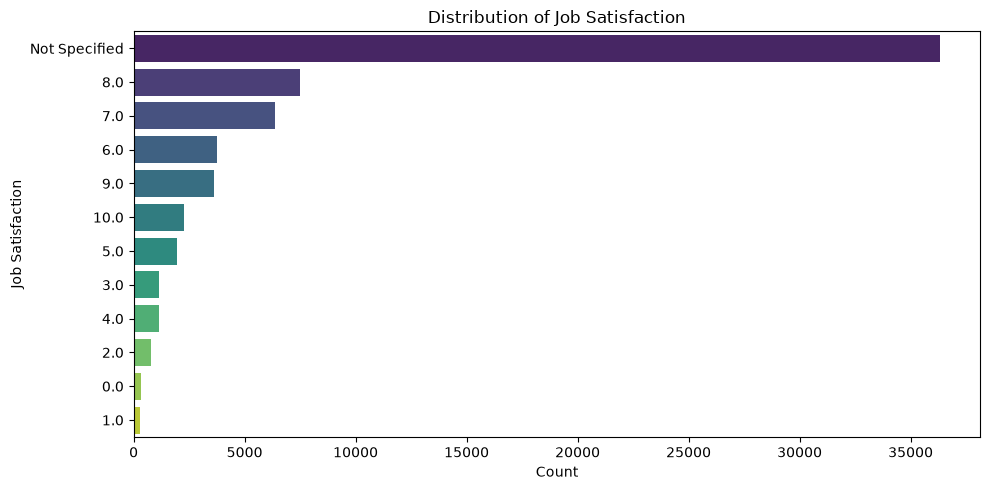

In [7]:
## Write your code here

# Visualize JobSat distribution using a countplot/bar chart (or pie chart)
plt.figure(figsize=(10, 5))
sns.countplot(y='JobSat', data=df, order=df['JobSat'].value_counts().index, palette='viridis')
plt.title('Distribution of Job Satisfaction')
plt.xlabel('Count')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


/tmp/ipykernel_1480/2570841832.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_worked_df.values, y=lang_worked_df.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1480/2570841832.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_want_df.values, y=lang_want_df.index, ax=axes[1], palette='Greens_r')

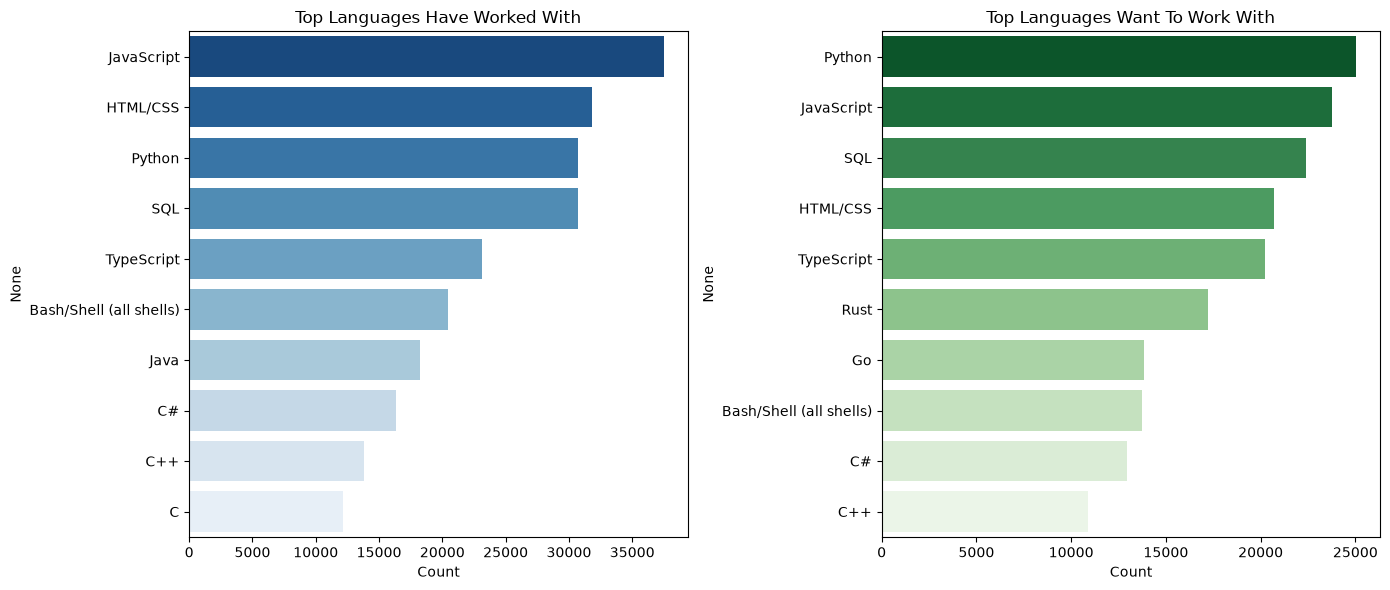

In [8]:
## Write your code here

# Compare LanguageHaveWorkedWith and LanguageWantToWorkWith
# Splitting semicolon-separated string values into individual languages
worked_with = df['LanguageHaveWorkedWith'].dropna().str.cat(sep=';').split(';')
want_work = df['LanguageWantToWorkWith'].dropna().str.cat(sep=';').split(';')

lang_worked_df = pd.Series(worked_with).value_counts().head(10)
lang_want_df = pd.Series(want_work).value_counts().head(10)

# Plotting the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=lang_worked_df.values, y=lang_worked_df.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top Languages Have Worked With')
axes[0].set_xlabel('Count')

sns.barplot(x=lang_want_df.values, y=lang_want_df.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top Languages Want To Work With')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


/tmp/ipykernel_1480/1938160005.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

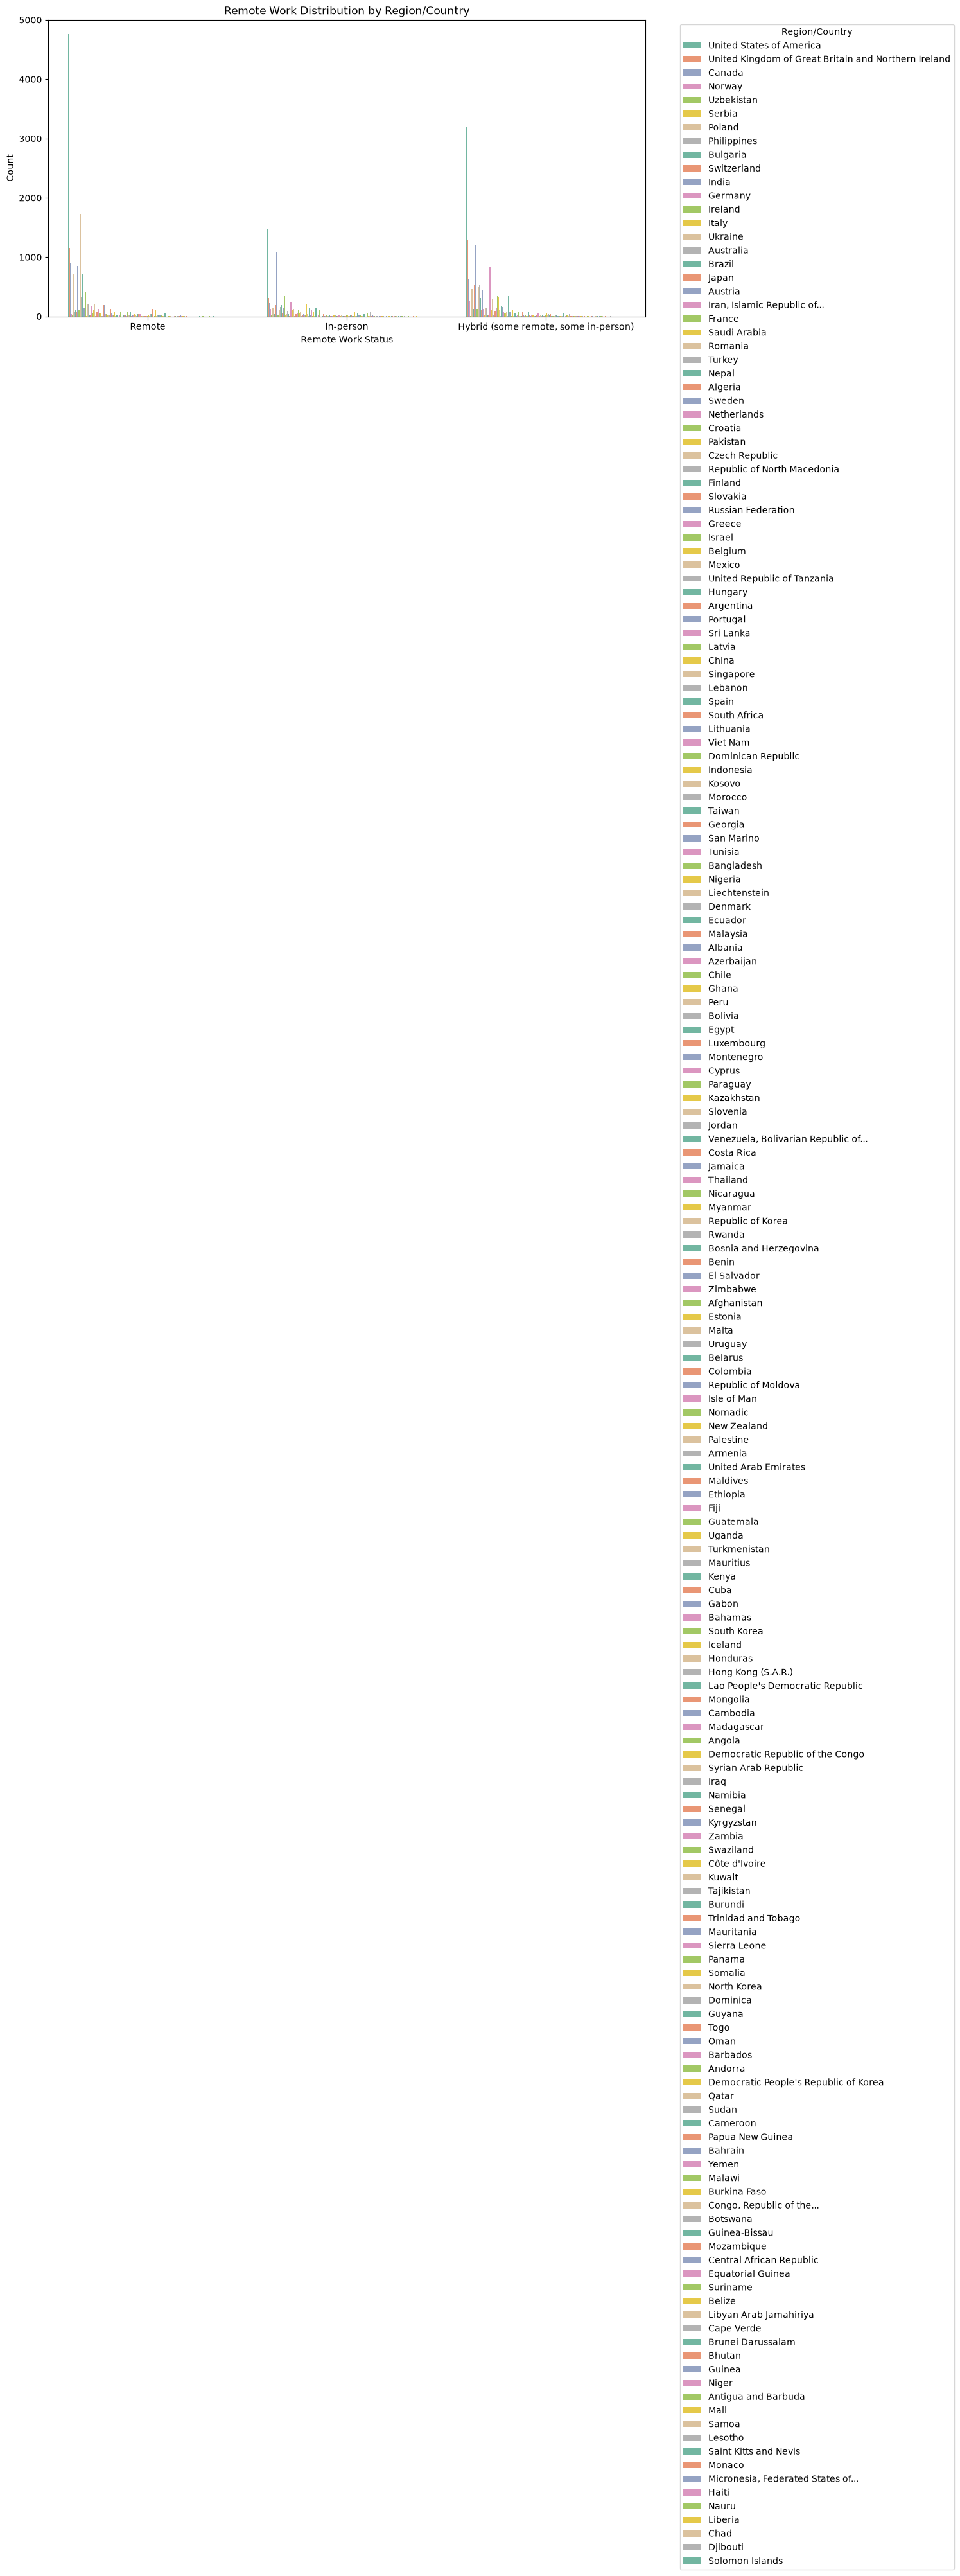

In [9]:
## Write your code here

# Visualize the distribution of RemoteWork by region using a countplot/grouped bar chart
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='RemoteWork', hue='Country', palette='Set2') # Adjust 'Country' or region column if named differently in your dataset
plt.title('Remote Work Distribution by Region/Country')
plt.xlabel('Remote Work Status')
plt.ylabel('Count')
plt.legend(title='Region/Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [11]:
## Write your code here

# Map categorical JobSat to numeric values
job_sat_map = {
    'Very satisfied': 5, 
    'Slightly satisfied': 4, 
    'Neither satisfied nor dissatisfied': 3, 
    'Slightly dissatisfied': 2, 
    'Very dissatisfied': 1
}
df['JobSat_Numeric'] = df['JobSat'].map(job_sat_map)

# Ensure YearsCodePro is numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Calculate correlation (using Spearman since ordinal/categorical ratings are involved)
correlation = df[['JobSat_Numeric', 'YearsCodePro']].corr(method='spearman')
print("Correlation Matrix (Job Satisfaction vs. Professional Experience):")
print(correlation)

Correlation Matrix (Job Satisfaction vs. Professional Experience):
                JobSat_Numeric  YearsCodePro
JobSat_Numeric             NaN           NaN
YearsCodePro               NaN           1.0

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-tabulation: Employment vs. Education Level

EdLevel,"Associate degree (A.A., A.S., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Primary/elementary school,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",Some college/university study without earning a degree,Something else
Employment,,,,,,,,
"Employed, full-time",1059,16806,11011,160,2073,1460,3579,377
"Employed, full-time;Employed, part-time",9,90,61,1,8,9,15,3
"Employed, full-time;Independent contractor, freelancer, or self-employed",104,1381,963,25,159,181,492,41
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",11,79,45,1,10,6,14,2
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired",0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
"Student, full-time;Student, part-time;Employed, part-time",0,1,1,1,0,0,4,0
"Student, full-time;Student, part-time;Retired",0,0,0,1,0,1,0,0
"Student, part-time",12,105,26,48,5,140,75,17


/tmp/ipykernel_1480/1728463911.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

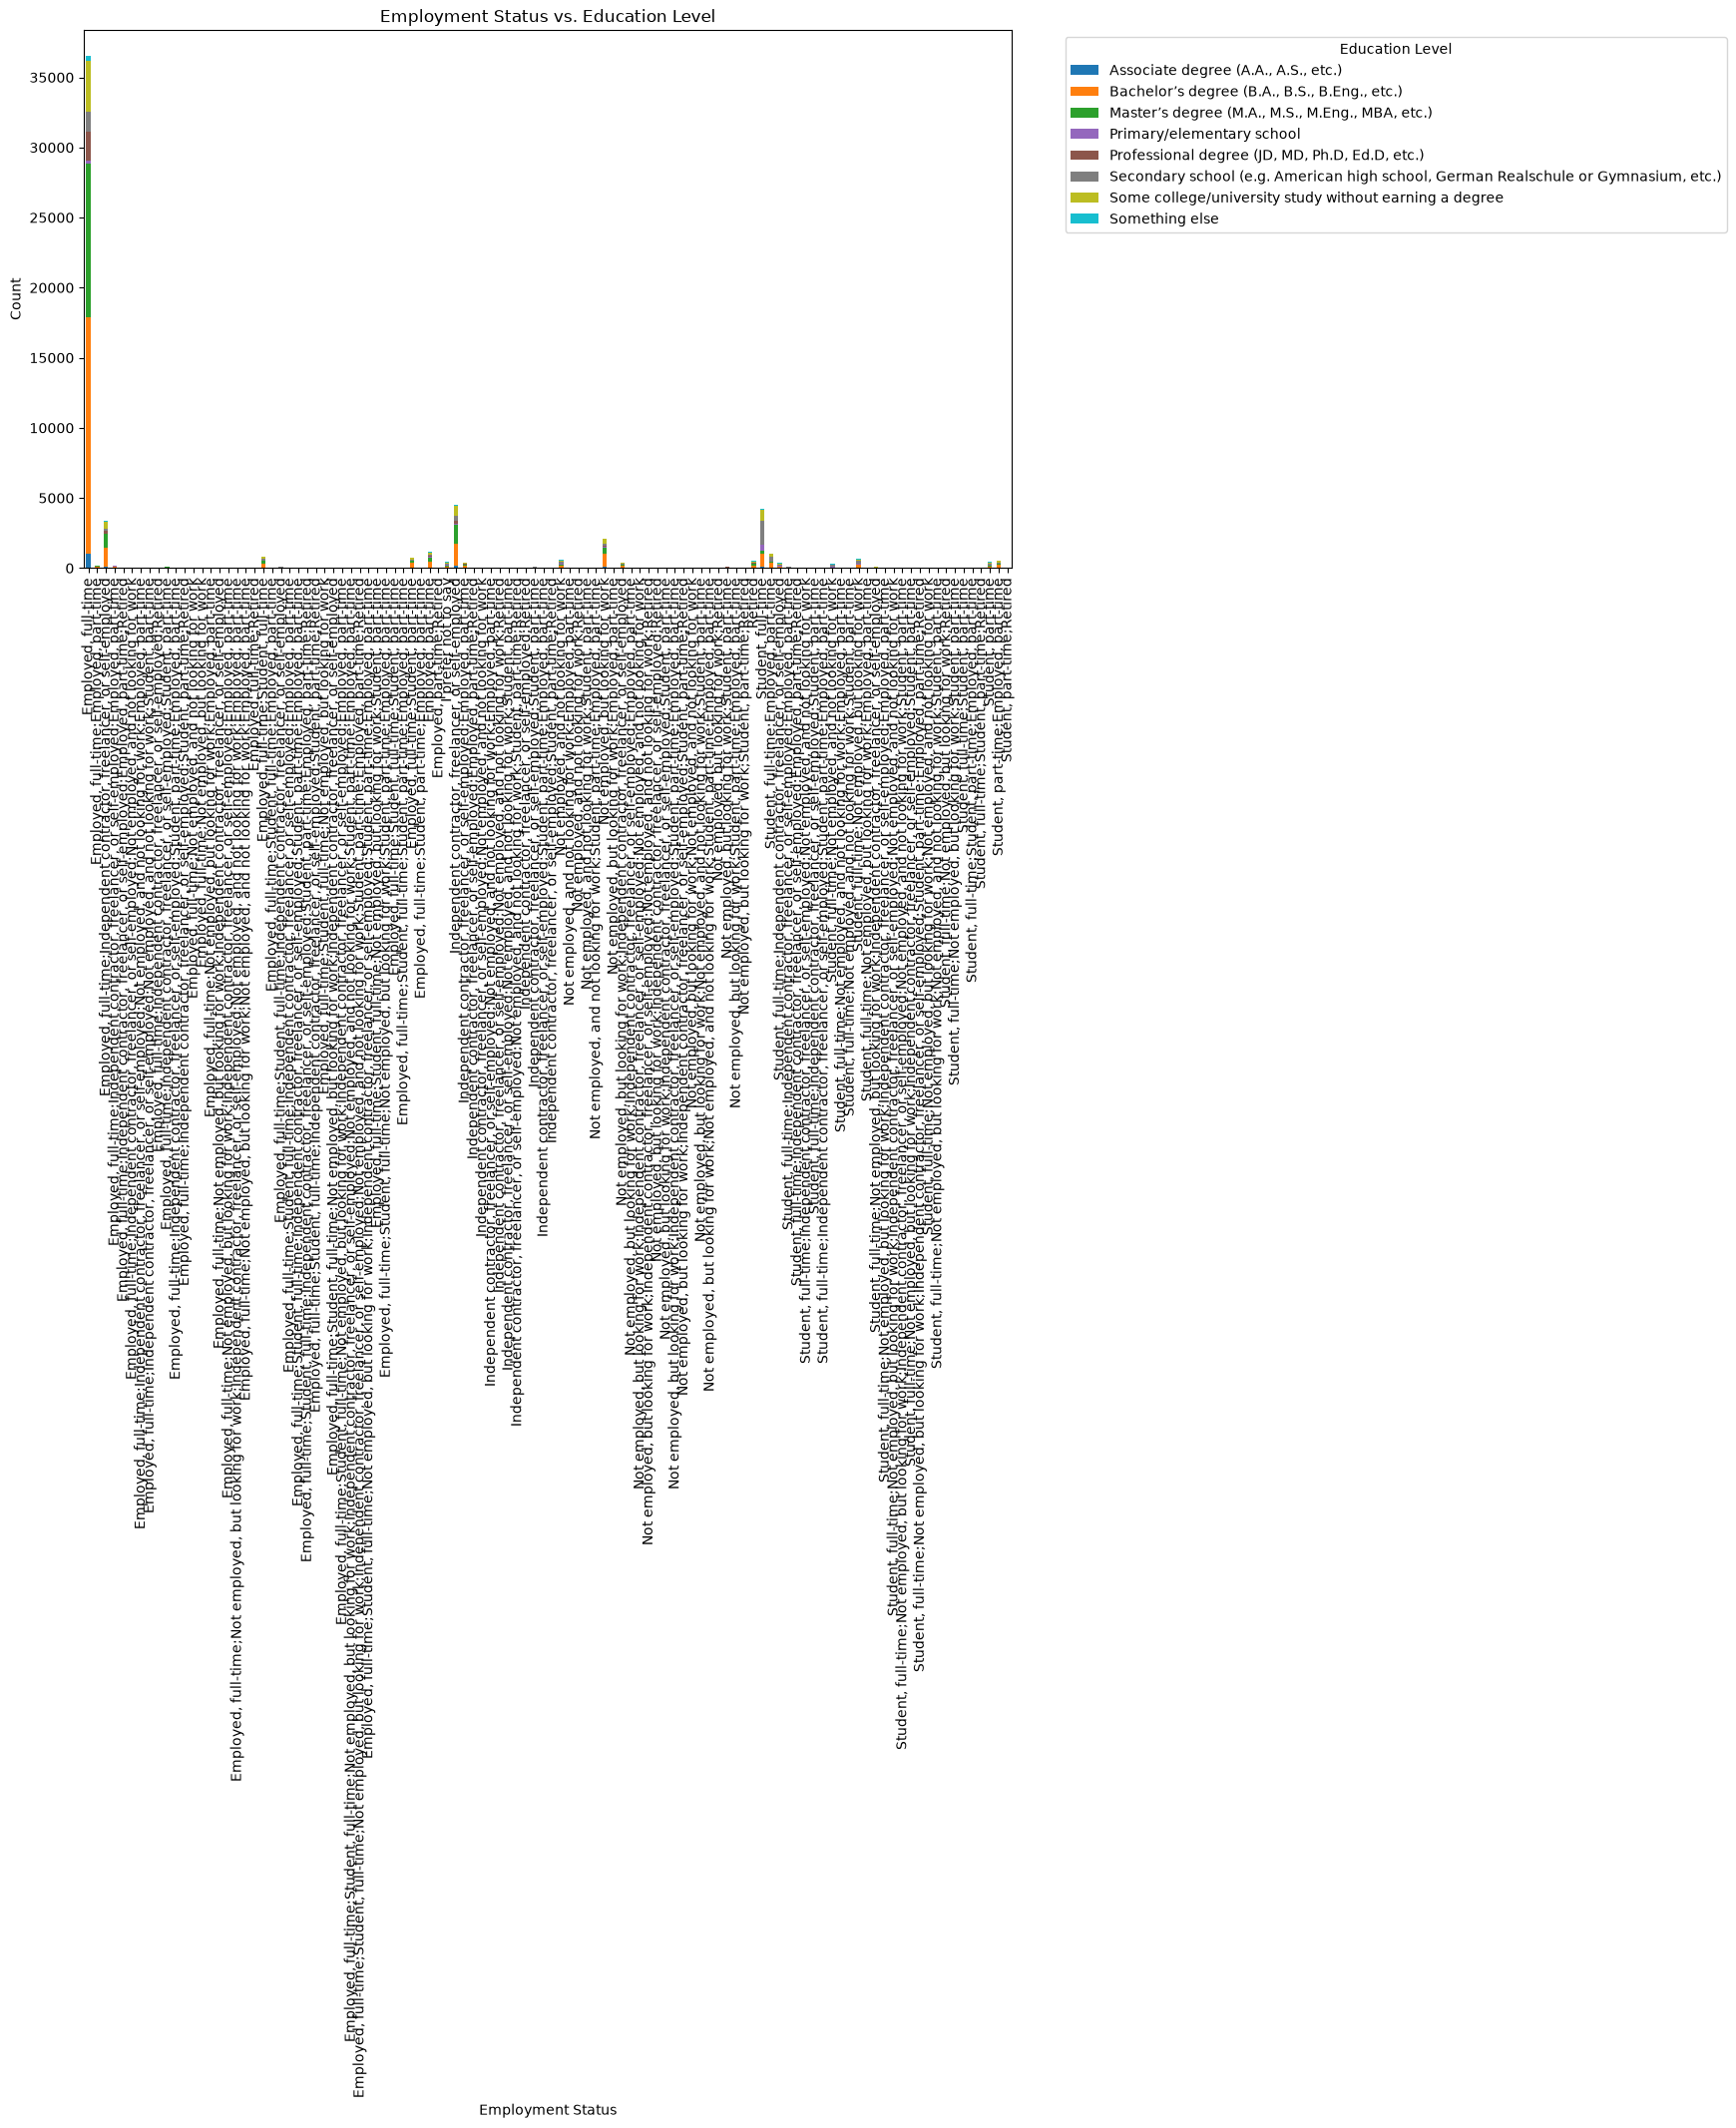

In [12]:
## Write your code here

# Create a cross-tabulation between Employment and EdLevel
cross_tab = pd.crosstab(df['Employment'], df['EdLevel'])
print("Cross-tabulation: Employment vs. Education Level")
display(cross_tab)

# Visualize with a stacked bar plot
cross_tab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')
plt.title('Employment Status vs. Education Level')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [13]:
## Write your code here

# Map categorical JobSat to numeric values
job_sat_map = {
    'Very satisfied': 5, 
    'Slightly satisfied': 4, 
    'Neither satisfied nor dissatisfied': 3, 
    'Slightly dissatisfied': 2, 
    'Very dissatisfied': 1
}
df['JobSat_Numeric'] = df['JobSat'].map(job_sat_map)

# Ensure YearsCodePro is numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Calculate correlation (using Spearman since ordinal/categorical ratings are involved)
correlation = df[['JobSat_Numeric', 'YearsCodePro']].corr(method='spearman')
print("Correlation Matrix (Job Satisfaction vs. Professional Experience):")
print(correlation)

Correlation Matrix (Job Satisfaction vs. Professional Experience):
                JobSat_Numeric  YearsCodePro
JobSat_Numeric             NaN           NaN
YearsCodePro               NaN           1.0

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
